## Basic Operations

In [2]:
# importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

In [45]:
# handling warnings 

import warnings
warnings.filterwarnings("ignore")

In [3]:
# importing our test data

test_data=pd.read_csv('cleaned_testing_data.csv')

In [4]:
# splitting independent and dependent features

X=test_data.drop(columns=['Diagnosis'], axis=1)         # independent features
y=test_data['Diagnosis']                                # dependent feature

## Logistic Regression

In [5]:
# loading our model

with open("logreg.pkl", "rb") as f:
    logreg = pickle.load(f)

In [6]:
# making predictions 

y_pred_logreg=logreg.predict(X)

In [29]:
# evaluating our model

cm_logreg=confusion_matrix(y_true=y, y_pred=y_pred_logreg)
cr_logreg=classification_report(y_true=y, y_pred=y_pred_logreg)
acc_score_logreg=accuracy_score(y_pred=y_pred_logreg, y_true=y)

print("Logistic Regression:\n")
print(f"Confusion Matrix:\n{cm_logreg}\n\nClassification Report:\n{cr_logreg}\nAccuracy Score:{acc_score_logreg}")

Logistic Regression:

Confusion Matrix:
[[107   1]
 [  3  60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       108
           1       0.98      0.95      0.97        63

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

Accuracy Score:0.9766081871345029


#### ROC AUC Analysis

In [8]:
# getting predicted probabilities

y_scores_logreg=logreg.predict_proba(X)[:,1]
fpr, tpr, thresholds=roc_curve(y_true=y, y_score=y_scores_logreg)
roc_auc_logreg=roc_auc_score(y_true=y, y_score=y_scores_logreg)

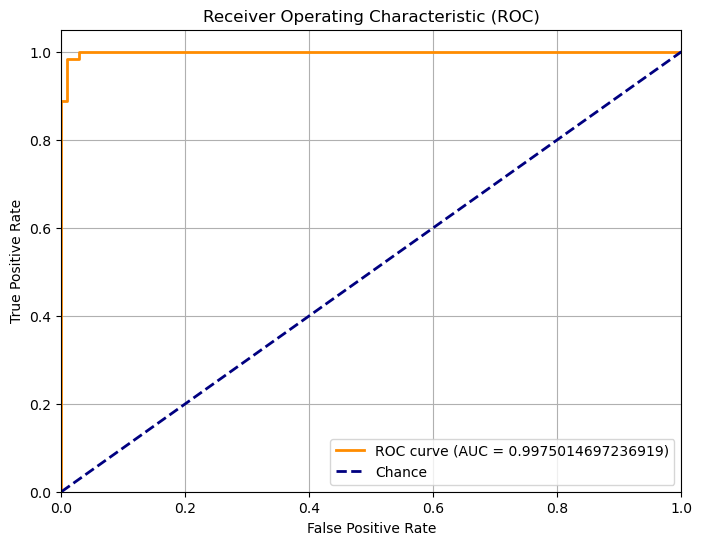

In [30]:
# plotting the roc_auc curve

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_logreg})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## KNN

In [10]:
# loading our model

with open("knn.pkl", "rb") as f:
    knn=pickle.load(f)

In [11]:
# making predictions

y_pred_knn=knn.predict(X)

In [31]:
# evaluating our model

cm_knn=confusion_matrix(y_true=y, y_pred=y_pred_knn)
cr_knn=classification_report(y_true=y, y_pred=y_pred_knn)
acc_score_knn=accuracy_score(y_pred=y_pred_knn, y_true=y)

print("KNeighborsClassifier:\n")
print(f"Confusion Matrix:\n{cm_knn}\n\nClassification Report:\n{cr_knn}\nAccuracy Score:{acc_score_knn}")

KNeighborsClassifier:

Confusion Matrix:
[[96 12]
 [16 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       108
           1       0.80      0.75      0.77        63

    accuracy                           0.84       171
   macro avg       0.83      0.82      0.82       171
weighted avg       0.83      0.84      0.84       171

Accuracy Score:0.8362573099415205


#### ROC AUC Analysis

In [13]:
# getting predicted probabilities

y_scores_knn=knn.predict_proba(X)[:,1]
fpr, tpr, thresholds=roc_curve(y_score=y_pred_knn, y_true=y)
roc_auc_knn=roc_auc_score(y_true=y, y_score=y_scores_knn)

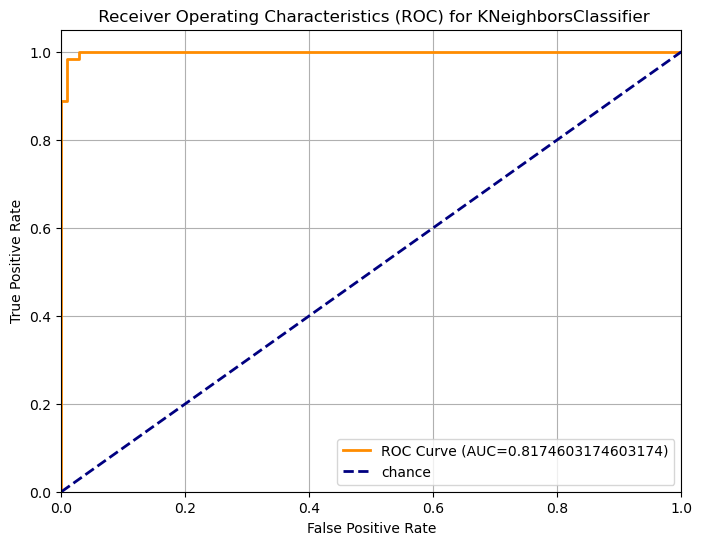

In [21]:
# plotting the roc_auc curve

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange',lw=2, label=f'ROC Curve (AUC={roc_auc_knn})')
plt.plot([0,1],[0,1], color='navy', lw=2, label='chance', linestyle="--")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0, 1.0])
plt.ylim([0, 1.05])
plt.title(" Receiver Operating Characteristics (ROC) for KNeighborsClassifier")
plt.legend(loc='lower right')
plt.grid()
plt.show()

## SVC

In [15]:
# loading our model

with open("svc.pkl", "rb") as f:
    svc=pickle.load(f)

In [16]:
# making predictions

y_pred_svc=svc.predict(X)

In [34]:
# evaluating our model

cm_svc=confusion_matrix(y_true=y, y_pred=y_pred_svc)
cr_svc=classification_report(y_true=y, y_pred=y_pred_svc)
acc_score_svc=accuracy_score(y_pred=y_pred_svc, y_true=y)

print("SVC:\n")
print(f"Confusion Matrix:\n{cm_svc}\n\nClassification Report:\n{cr_svc}\nAccuracy Score:{acc_score_svc}")

SVC:

Confusion Matrix:
[[107   1]
 [  1  62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       108
           1       0.98      0.98      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

Accuracy Score:0.9883040935672515


#### ROC AUC Analysis

In [18]:
# getting predicted probabilities

y_scores_svc=svc.decision_function(X)
fpr, tpr, thresholds=roc_curve(y_true=y, y_score=y_scores_svc)
roc_auc_svc=roc_auc_score(y_true=y, y_score=y_scores_svc)

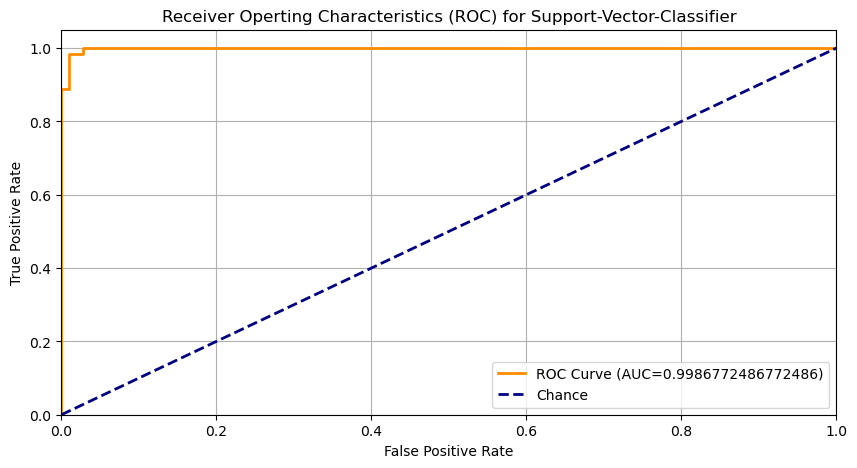

In [24]:
# plotting the roc_auc curve

plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC={roc_auc_svc})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operting Characteristics (ROC) for Support-Vector-Classifier")
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Exporting our Best Model

#### Comparing the 3 Models

Accuracy Score:

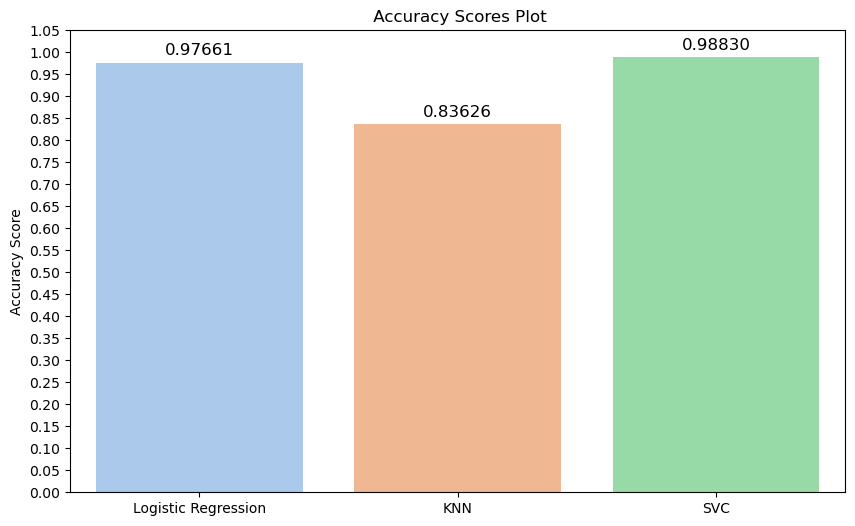

In [54]:
estimator_names=['Logistic Regression', 'KNN', 'SVC']
acc_scores=[acc_score_logreg, acc_score_knn, acc_score_svc]

plt.figure(figsize=(10,6))
plt.ylabel("Accuracy Score")
plt.title(" Accuracy Scores Plot")
ax=sns.barplot(x=estimator_names, y=acc_scores, palette='pastel')
for i, acc in enumerate(acc_scores):
    ax.text(i, acc + 0.01, f"{acc:.5f}", ha='center', va='bottom', fontsize=12)

# Y-axis calibration
import matplotlib.ticker as mtick
ax.set_yticks(np.arange(0, 1.1, 0.05))        # Tick every 0.05
ax.set_ylim(0, 1.05)                          # Range from 0 to slightly above 1
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}'))  # Format to 2 decimals

Precision Recall:

In [35]:
with open(file='cancer_classification_model.pkl', mode="wb") as f:
    pickle.dump(svc,f)